In [ ]:
from google.colab import drive, files
drive.mount('/content/drive', force_remount=True)

In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

# === 資料路徑 ===
CSV_PATH = "/content/drive/MyDrive/BL0909/M/ALL.csv"


In [5]:
import pandas as pd
import numpy as np

# ===== 讀 CSV =====
df = pd.read_csv(CSV_PATH)

# ===== 檢查欄位 =====
print("欄位名稱：", df.columns.tolist())

# ===== 特徵與標籤 =====
# 假設最後一欄是 label，其餘都是光譜
X = df.iloc[:, :-1].to_numpy(dtype=np.float32)
y = df.iloc[:, -1].astype(str).str.upper().str.strip()

print("類別：", np.unique(y))

# ===== Conv1D 輸入 reshape =====
X_seq = X.reshape((X.shape[0], X.shape[1], 1))

# ===== 輸出確認 =====
print("CNN 輸入:", X_seq.shape)
print("樣本數:", X.shape[0])
print("波段數:", X.shape[1])

欄位名稱： ['366.217137', '366.7177379535301', '367.2184383483211', '367.71923808567374', '368.2201370668889', '368.72113519326746', '369.22223236611023', '369.723428486718', '370.2247234563917', '370.726117176432', '371.22760954814', '371.72920047281633', '372.2308898517619', '372.73267758627753', '373.2345635776641', '373.7365477272225', '374.2386299362534', '374.7408101060578', '375.24308813793647', '375.7454639331903', '376.24793739312', '376.7505084190265', '377.2531769122107', '377.75594277397335', '378.25880590561536', '378.7617662084375', '379.2648235837406', '379.7679779328256', '380.2712291569933', '380.77457715754446', '381.27802183578', '381.7815630930007', '382.2852008305075', '382.7889349496012', '383.29276535158255', '383.7966919377525', '384.30071460941184', '384.8048332678614', '385.3090478144021', '385.8133581503346', '386.31776417696', '386.8222657955789', '387.3268629074923', '387.83155541400095', '388.33634321640574', '388.8412262160075', '389.346204314107', '389.851277

讀取資料 (ALL.csv)

光譜資料共 1232 波段。

最後一欄是標籤（BG / PET / PP / PS）。

In [6]:
label_map = {"BG": 0, "PET": 1, "PP": 2, "PS": 3}
y = y.map(label_map).to_numpy()
y = to_categorical(y, num_classes=4)
print("標籤 one-hot:", y.shape)


標籤 one-hot: (71808, 4)


資料前處理

光譜 reshape → (N, 1232, 1)（CNN 分支用）。


標籤 one-hot 編碼 → (N, 4)。

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

# ===== 打亂資料 =====
X_seq, y = shuffle(X_seq, y, random_state=42)

# ===== 切訓練 / 驗證 =====
X_train, X_val, y_train, y_val = train_test_split(
    X_seq, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # 👉 很重要：避免類別不平均
)

print("訓練集:", X_train.shape, y_train.shape)
print("驗證集:", X_val.shape, y_val.shape)


訓練集: (57446, 1232, 1) (57446, 4)
驗證集: (14362, 1232, 1) (14362, 4)


In [16]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

num_classes = 4   # BG, PET, PP, PS

input_seq = Input(shape=(X_train.shape[1], 1))

x = Conv1D(filters=32, kernel_size=5, activation="relu", padding="same")(input_seq)
x = MaxPooling1D(pool_size=2)(x)

x = Conv1D(filters=64, kernel_size=5, activation="relu", padding="same")(x)
x = MaxPooling1D(pool_size=2)(x)

x = Flatten()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)
output = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=input_seq, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1232, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 1232, 32)       │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 616, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 616, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 308, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 19712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     2,523,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,534,276 (9.67 MB)

 Trainable params: 2,534,276 (9.67 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train_enc,
    epochs=20,
    batch_size=128,
    validation_data=(X_val, y_val_enc),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 157s 343ms/step - accuracy: 0.8660 - loss: 0.5904 - val_accuracy: 0.9801 - val_loss: 0.0672
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 161s 359ms/step - accuracy: 0.9503 - loss: 0.1309 - val_accuracy: 0.9843 - val_loss: 0.0481
Epoch 3/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 160s 355ms/step - accuracy: 0.9557 - loss: 0.1152 - val_accuracy: 0.9904 - val_loss: 0.0310
Epoch 4/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 235s 428ms/step - accuracy: 0.9607 - loss: 0.1033 - val_accuracy: 0.9823 - val_loss: 0.0526
Epoch 5/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 186s 413ms/step - accuracy: 0.9614 - loss: 0.0963 - val_accuracy: 0.9914 - val_loss: 0.0272
Epoch 6/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 170s 379ms/step - accuracy: 0.9649 - loss: 0.0827 - val_accuracy: 0.9912 - val_loss: 0.0273
Epoch 7/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 204s 383ms/step - accuracy: 0.9619 - loss: 0.0934 - val_accuracy: 0.9919 - val_loss: 0.0228
Epoch 8/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 172s 384ms/step - accuracy: 0.9665 -

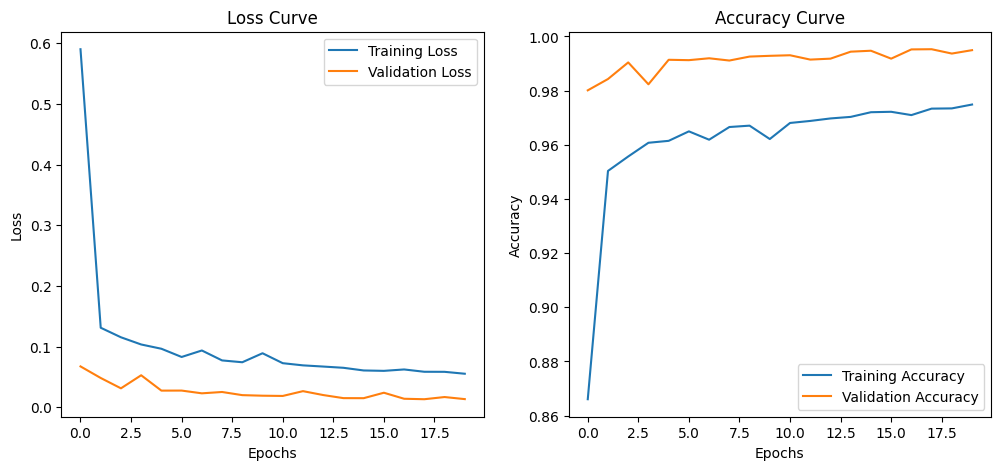

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.show()


輸出

模型存成 .keras 檔案，供推論使用。

In [25]:
import os

# 設定輸出資料夾
OUT_DIR = "/content/drive/MyDrive/BL0909/M/MODEL"
os.makedirs(OUT_DIR, exist_ok=True)

# 模型檔案路徑
MODEL_PATH = os.path.join(OUT_DIR, "Conv1D_BL20260331.keras")

# 儲存模型
model.save(MODEL_PATH)
print(f"✅ 模型已儲存: {MODEL_PATH}")

# 測試載入
from tensorflow.keras.models import load_model
loaded_model = load_model(MODEL_PATH, compile=False)
loaded_model.summary()


✅ 模型已儲存: /content/drive/MyDrive/BL0909/M/MODEL/Conv1D_BL20260331.keras


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1232, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 1232, 32)       │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 616, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 616, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 308, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 19712)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │     2,523,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,534,276 (9.67 MB)

 Trainable params: 2,534,276 (9.67 MB)

 Non-trainable params: 0 (0.00 B)

Pixel Accuracy: 0.99526528

Classification Report:
              precision    recall  f1-score   support

          BL     0.9892    0.9947    0.9919      3590
         PET     0.9952    0.9864    0.9908      3591
          PP     0.9967    1.0000    0.9983      3590
          PS     1.0000    1.0000    1.0000      3591

    accuracy                         0.9953     14362
   macro avg     0.9953    0.9953    0.9953     14362
weighted avg     0.9953    0.9953    0.9953     14362


Confusion Matrix:
[[3571   17    2    0]
 [  39 3542   10    0]
 [   0    0 3590    0]
 [   0    0    0 3591]]


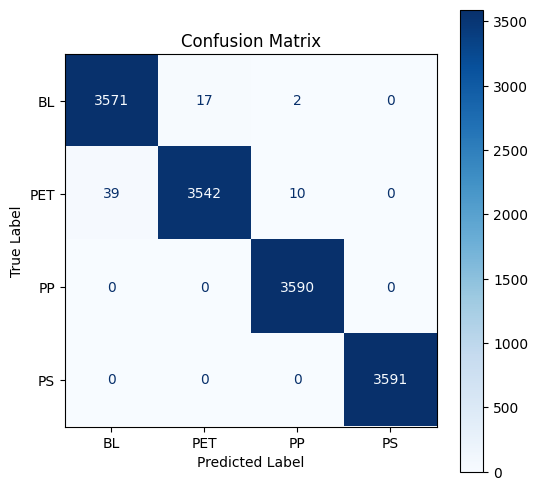

In [27]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

LABELS = ["BL", "PET", "PP", "PS"]

# ===== 驗證集預測 =====
y_prob = model.predict(X_val, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

# ===== 真實標籤 =====
if len(y_val.shape) > 1:
    y_true = np.argmax(y_val, axis=1)
else:
    y_true = y_val

# 如果你訓練時用的是 y_val_enc，也可直接：
# y_true = y_val_enc

# ===== 像素準確率 =====
pixel_acc = accuracy_score(y_true, y_pred)
print(f"Pixel Accuracy: {pixel_acc:.8f}")

# ===== 分類報告 =====
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=LABELS, digits=4))

# ===== 混淆矩陣 =====
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

fig, ax = plt.subplots(figsize=(6, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=True)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [23]:
print("Correct predictions:", (y_true == y_pred).sum())
print("Total samples:", len(y_true))

Correct predictions: 14294
Total samples: 14362
